<a href="https://colab.research.google.com/github/AndreiMatosha/ML-Basic/blob/main/homework_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Airbnb 2019 — EDA & Preprocessing
**Датасет:** [Kaggle — New York City Airbnb Open Data](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data)

**Содержание:**
1. Импорты и загрузка данных
2. Удаление ненужных признаков
3. Визуализация: пропуски
4. Визуализация: распределения числовых признаков
5. Визуализация: распределения категориальных признаков
6. Матрица попарных корреляций
7. Pair plots
8. Цена по категориям
9. Географическая карта
10. Предобработка: удаление ошибок
11. Предобработка: заполнение пропусков
12. Предобработка: IQR-обрезка выбросов
13. Предобработка: log1p-трансформация
14. Предобработка: кодирование категорий
15. Предобработка: масштабирование
16. Итоговый датасет

## 1. Импорты и загрузка данных

In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PAL = sns.color_palette('muted')

# Загрузка
df_raw = pd.read_csv('/root/.cache/kagglehub/datasets/dgomonov/new-york-city-airbnb-open-data/versions/3/AB_NYC_2019.csv')
print(f'Форма датасета: {df_raw.shape}')
df_raw.head()

Форма датасета: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [43]:
# Типы данных и базовая информация
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [44]:
# Описательные статистики
df_raw.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 2. Удаление ненужных признаков

In [45]:
DROP_COLS = ['id', 'name', 'host_id', 'host_name', 'last_review']

df = df_raw.drop(columns=DROP_COLS)

print(f'Было признаков: {df_raw.shape[1]}')
print(f'Стало признаков: {df.shape[1]}')
print(f'Удалены: {DROP_COLS}')
print(f'Остались: {list(df.columns)}')

Было признаков: 16
Стало признаков: 11
Удалены: ['id', 'name', 'host_id', 'host_name', 'last_review']
Остались: ['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [46]:
# Удобные списки признаков по типу
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews',
                'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
cat_cols     = ['neighbourhood_group', 'neighbourhood', 'room_type']
geo_cols     = ['latitude', 'longitude']

## 3. Визуализация: пропущенные значения

In [47]:
# Подсчёт пропусков
miss = df.isnull().sum()
print('Пропуски по признакам:')
print(miss.to_string())

Пропуски по признакам:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0


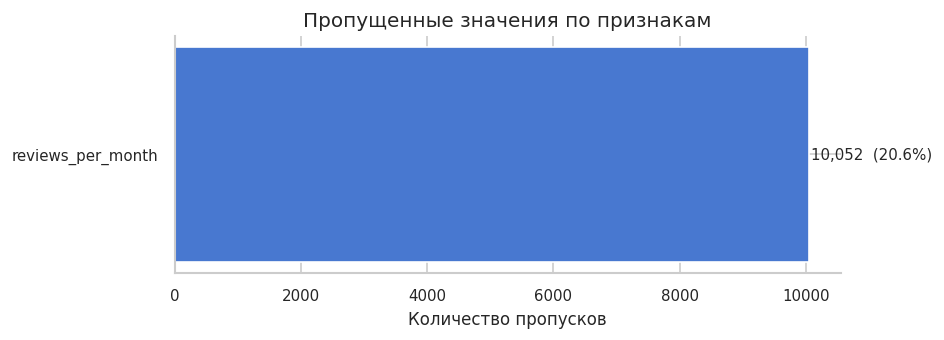

In [48]:
# Визуализация пропусков
miss_nonzero = miss[miss > 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(miss_nonzero.index, miss_nonzero.values, color=PAL[0], edgecolor='white')

for bar, v in zip(bars, miss_nonzero.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{v:,}  ({v / len(df) * 100:.1f}%)', va='center', fontsize=9)

ax.set_title('Пропущенные значения по признакам')
ax.set_xlabel('Количество пропусков')
plt.tight_layout()
plt.show()

**Вывод:** только `reviews_per_month` имеет пропуски — 10 052 строки (≈20.6%).
Это объявления без ни одного отзыва, поэтому семантически корректно заменить NaN на 0.

## 4. Визуализация: распределения числовых признаков

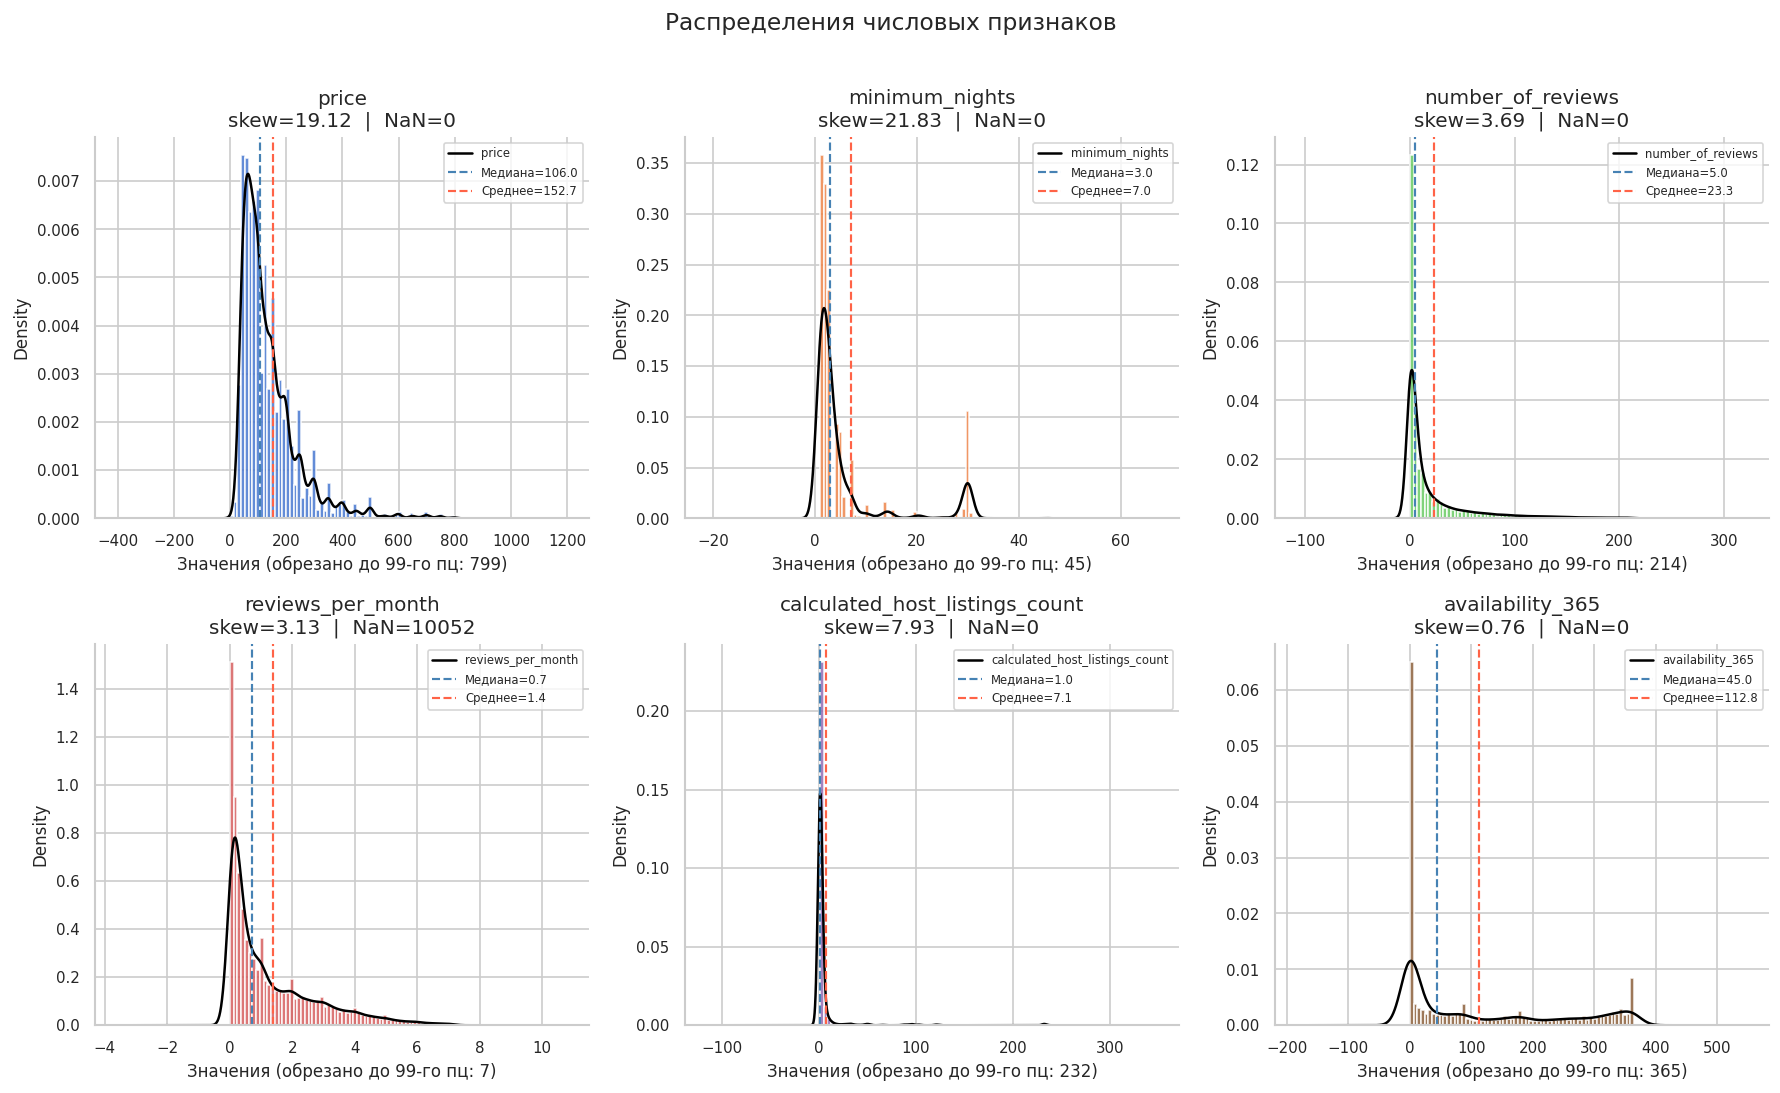

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax   = axes[i]
    data = df[col].dropna()
    p99  = data.quantile(0.99)
    vis  = data[data <= p99]          # обрезаем для читаемости

    ax.hist(vis, bins=60, color=PAL[i], edgecolor='white', alpha=0.85, density=True)
    vis.plot.kde(ax=ax, color='black', linewidth=1.5)

    ax.axvline(data.median(), color='steelblue', ls='--', lw=1.3,
               label=f'Медиана={data.median():.1f}')
    ax.axvline(data.mean(),   color='tomato',    ls='--', lw=1.3,
               label=f'Среднее={data.mean():.1f}')

    ax.set_title(f'{col}\nskew={stats.skew(data):.2f}  |  NaN={df[col].isna().sum()}')
    ax.set_xlabel(f'Значения (обрезано до 99-го пц: {p99:.0f})')
    ax.legend(fontsize=7)

plt.suptitle('Распределения числовых признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [50]:
# Таблица асимметрии и квартилей
summary_rows = []
for col in numeric_cols:
    d = df[col].dropna()
    summary_rows.append({
        'признак': col,
        'min': d.min(), 'Q1': d.quantile(0.25),
        'median': d.median(), 'Q3': d.quantile(0.75),
        'max': d.max(), 'mean': d.mean(),
        'skew': round(stats.skew(d), 2),
        'NaN': df[col].isna().sum()
    })

pd.DataFrame(summary_rows).set_index('признак').round(2)

,min,Q1,median,Q3,max,mean,skew,NaN
признак,,,,,,,,
price,0.00,69.00,106.00,175.00,10000.0,152.72,19.12,0
minimum_nights,1.00,1.00,3.00,5.00,1250.0,7.03,21.83,0
number_of_reviews,0.00,1.00,5.00,24.00,629.0,23.27,3.69,0
reviews_per_month,0.01,0.19,0.72,2.02,58.5,1.37,3.13,10052
calculated_host_listings_count,1.00,1.00,1.00,2.00,327.0,7.14,7.93,0
availability_365,0.00,0.00,45.00,227.00,365.0,112.78,0.76,0


**Вывод:** `price` (skew=19), `minimum_nights` (skew=22), `calculated_host_listings_count` (skew=8)  
— сильно скошены вправо. Необходимы обрезка выбросов и log-трансформация.

## 5. Визуализация: распределения категориальных признаков

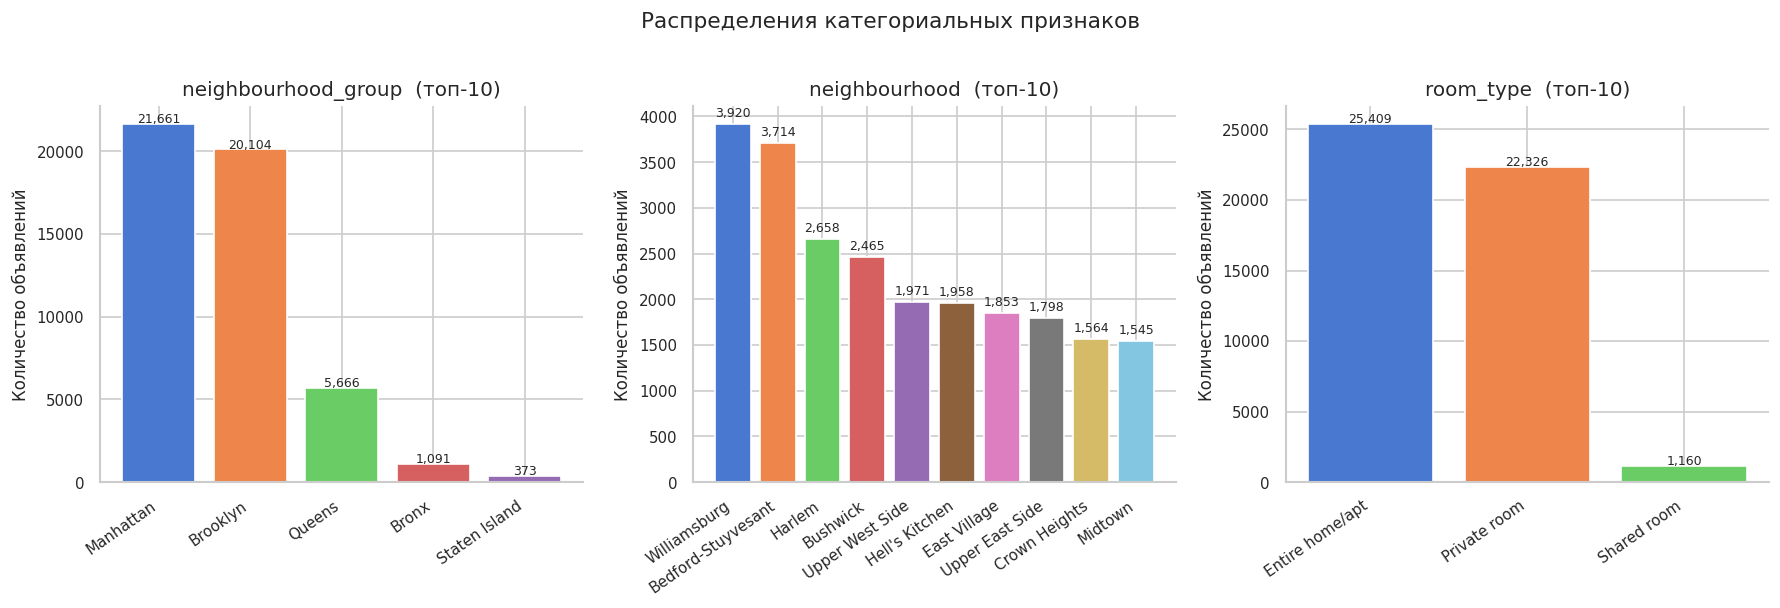

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = df[col].value_counts().head(10)
    bars = ax.bar(range(len(vc)), vc.values,
                  color=PAL[:len(vc)], edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=35, ha='right')
    ax.set_title(f'{col}  (топ-10)')
    ax.set_ylabel('Количество объявлений')
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 80,
                f'{v:,}', ha='center', fontsize=7.5)

plt.suptitle('Распределения категориальных признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [52]:
# Уникальные значения
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} уникальных значений')
    print(df[col].value_counts().head(5).to_string(), '\n')

neighbourhood_group: 5 уникальных значений
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373 

neighbourhood: 221 уникальных значений
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971 

room_type: 3 уникальных значений
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160 



**Вывод:**
- `neighbourhood_group` — 5 значений → **one-hot encoding**  
- `room_type` — 3 значения → **ordinal encoding** (Shared < Private < Entire)  
- `neighbourhood` — 221 значение → **frequency encoding** (label/one-hot нецелесообразен)

## 6. Матрица попарных корреляций

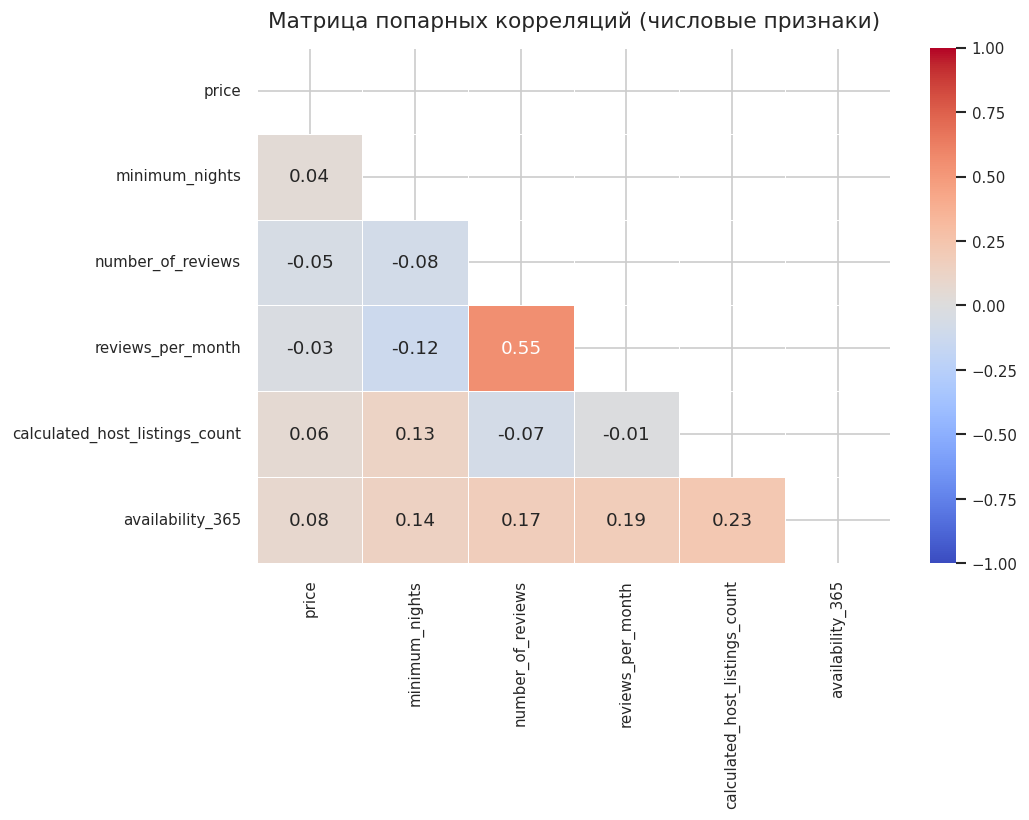

In [53]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # показываем только нижний треугольник

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.6, linecolor='white',
    annot_kws={'size': 11}, ax=ax
)
ax.set_title('Матрица попарных корреляций (числовые признаки)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [54]:
# Топ-5 пар по абсолютной корреляции
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
corr_pairs.sort_values('abs_corr', ascending=False).head(5)

,feature_1,feature_2,correlation,abs_corr
5,reviews_per_month,number_of_reviews,0.549868,0.549868
14,availability_365,calculated_host_listings_count,0.225701,0.225701
13,availability_365,reviews_per_month,0.185791,0.185791
12,availability_365,number_of_reviews,0.172028,0.172028
11,availability_365,minimum_nights,0.144303,0.144303


**Вывод:** признаки слабо коррелируют между собой.  
Наиболее заметная связь — `number_of_reviews` ↔ `reviews_per_month` (~0.6), что логично:  
чем больше отзывов всего, тем выше среднемесячная активность.

## 7. Pair Plots

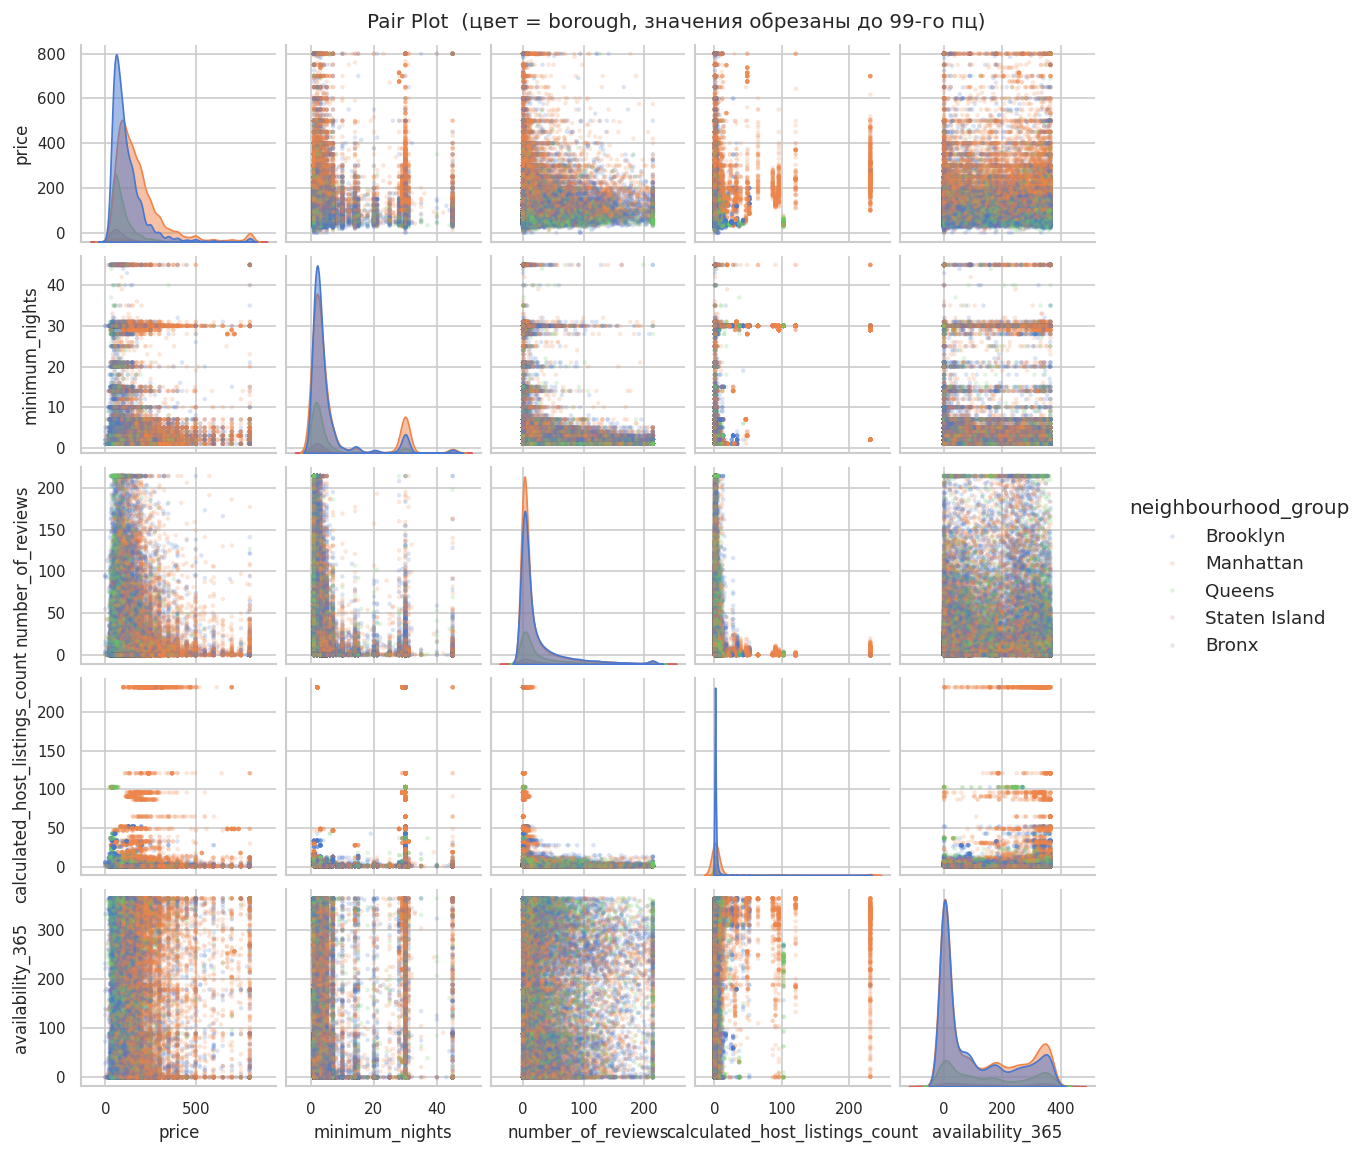

In [55]:
pp_cols = ['price', 'minimum_nights', 'number_of_reviews',
           'calculated_host_listings_count', 'availability_365']

df_pp = df[pp_cols + ['neighbourhood_group']].copy()

# Обрезаем до 99-го перцентиля для читаемости
for c in pp_cols:
    df_pp[c] = df_pp[c].clip(upper=df_pp[c].quantile(0.99))

g = sns.pairplot(
    df_pp.dropna(),
    hue='neighbourhood_group',
    diag_kind='kde',
    plot_kws={'alpha': 0.2, 's': 7, 'linewidth': 0},
    diag_kws={'fill': True, 'alpha': 0.5},
    height=1.9,
    palette='muted'
)
g.figure.suptitle('Pair Plot  (цвет = borough, значения обрезаны до 99-го пц)',
                  y=1.01, fontsize=12)
plt.show()

## 8. Цена по категориям

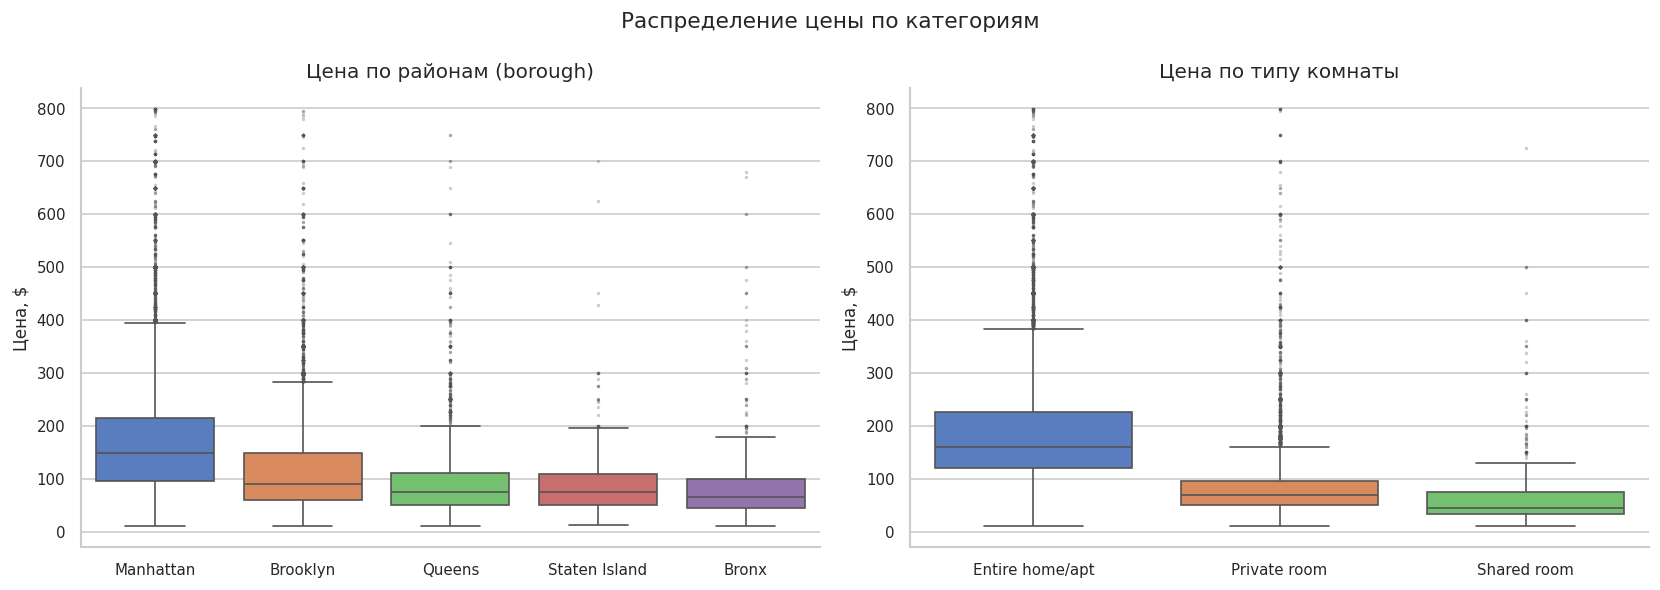

In [56]:
price_cap = df['price'].quantile(0.99)
df_vis    = df[df['price'].between(1, price_cap)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По borough
ng_order = (df_vis.groupby('neighbourhood_group')['price']
            .median().sort_values(ascending=False).index)
sns.boxplot(data=df_vis, x='neighbourhood_group', y='price',
            order=ng_order, palette='muted', ax=axes[0],
            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
axes[0].set_title('Цена по районам (borough)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Цена, $')

# По типу комнаты
rt_order = (df_vis.groupby('room_type')['price']
            .median().sort_values(ascending=False).index)
sns.boxplot(data=df_vis, x='room_type', y='price',
            order=rt_order, palette='muted', ax=axes[1],
            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
axes[1].set_title('Цена по типу комнаты')
axes[1].set_xlabel('')
axes[1].set_ylabel('Цена, $')

plt.suptitle('Распределение цены по категориям', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Географическая карта (бонус)

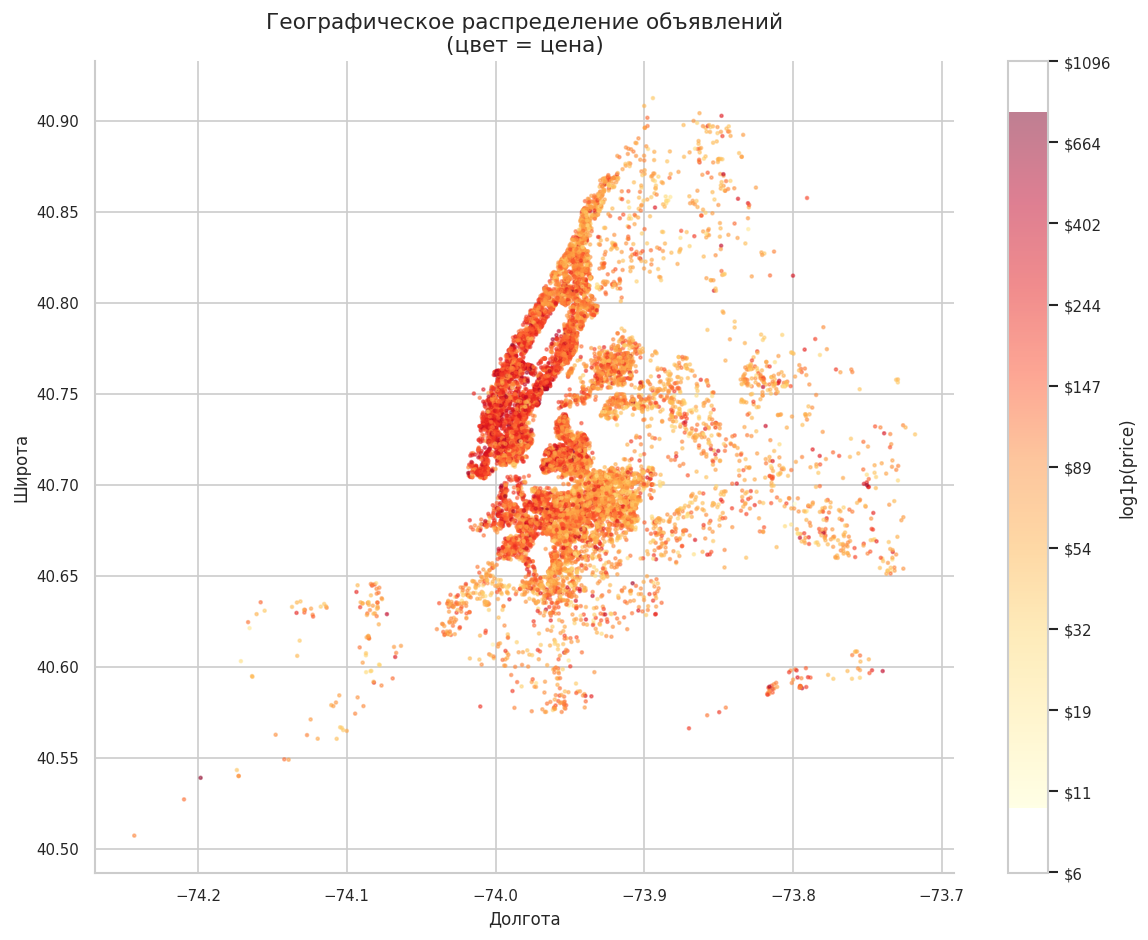

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))

df_geo = df[df['price'].between(1, price_cap)].sample(15000, random_state=42)
sc = ax.scatter(
    df_geo['longitude'], df_geo['latitude'],
    c=np.log1p(df_geo['price']),
    cmap='YlOrRd', s=3, alpha=0.5
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log1p(price)')
ticks = cbar.get_ticks()
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'${np.expm1(t):.0f}' for t in ticks])

ax.set_title('Географическое распределение объявлений\n(цвет = цена)', fontsize=13)
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
plt.tight_layout()
plt.show()

---
# Предобработка данных

Все шаги выполняются на копии датасета `df_proc`, чтобы не портить исходный `df`.

## 10. Удаление строк с price == 0

In [58]:
df_proc = df.copy()

n_zeros = (df_proc['price'] == 0).sum()
print(f'Строк с price=0: {n_zeros}')

df_proc = df_proc[df_proc['price'] > 0].copy()
print(f'Строк после удаления: {len(df_proc)}')

Строк с price=0: 11
Строк после удаления: 48884


**Обоснование:** цена 0 — явная ошибка данных.  
Такие объявления нельзя забронировать и они искажают статистику.

## 11. Заполнение пропусков

In [59]:
print('До:', df_proc['reviews_per_month'].isna().sum(), 'пропусков')

df_proc['reviews_per_month'] = df_proc['reviews_per_month'].fillna(0)

print('После:', df_proc['reviews_per_month'].isna().sum(), 'пропусков')
print('\nПроверка — пропуски во всём датасете:')
print(df_proc.isnull().sum().to_string())

До: 10051 пропусков
После: 0 пропусков

Проверка — пропуски во всём датасете:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0


**Обоснование:** `reviews_per_month = NaN` означает, что у объявления ещё не было ни одного отзыва.  
Это не «неизвестное» значение, а осмысленный ноль — пропуск заполнён семантически.

## 12. IQR-обрезка выбросов

In [60]:
def iqr_clip(series, k=3.0):
    """Обрезает значения за пределами [Q1 - k*IQR, Q3 + k*IQR]."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    return series.clip(lower=q1 - k * iqr, upper=q3 + k * iqr)

clip_cols = ['price', 'minimum_nights',
             'number_of_reviews', 'calculated_host_listings_count']

print('IQR-обрезка (k=3):')
for col in clip_cols:
    before_max = df_proc[col].max()
    df_proc[col] = iqr_clip(df_proc[col])
    after_max  = df_proc[col].max()
    print(f'  {col:<40} max: {before_max:.0f} → {after_max:.0f}')

IQR-обрезка (k=3):
  price                                    max: 10000 → 493
  minimum_nights                           max: 1250 → 17
  number_of_reviews                        max: 629 → 93
  calculated_host_listings_count           max: 327 → 5


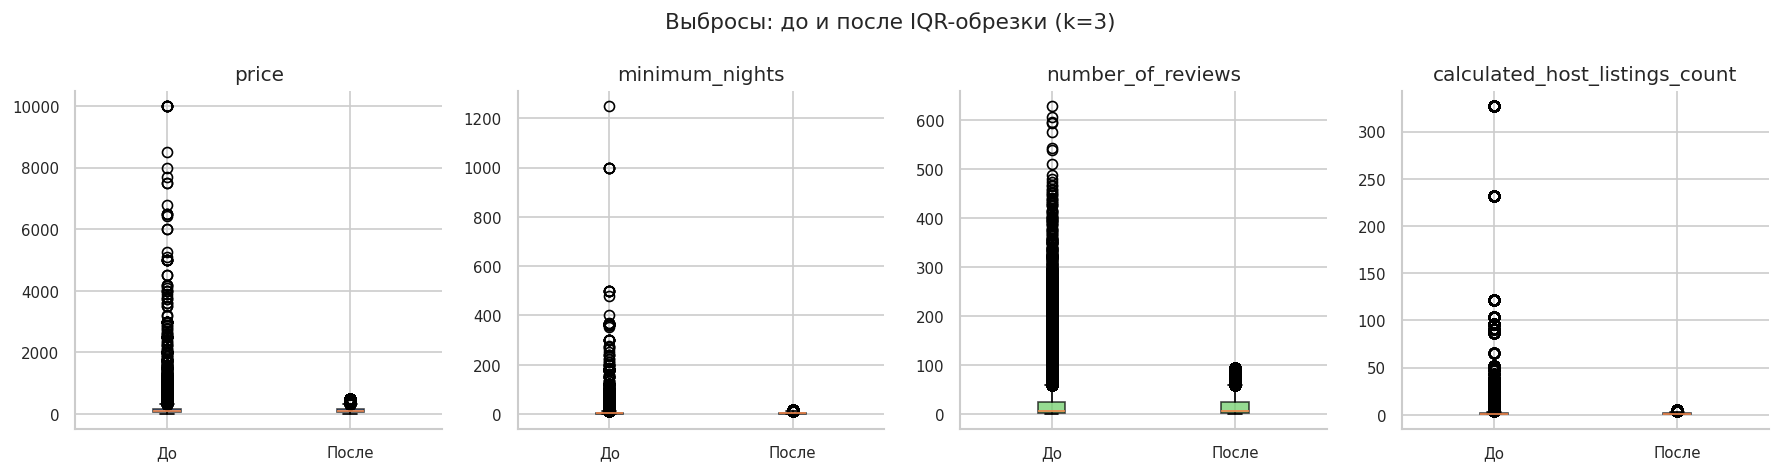

In [61]:
# Визуализация: boxplots до и после обрезки
fig, axes = plt.subplots(1, len(clip_cols), figsize=(15, 4))

for i, col in enumerate(clip_cols):
    axes[i].boxplot(
        [df[df['price'] > 0][col].dropna(), df_proc[col]],
        labels=['До', 'После'],
        patch_artist=True,
        boxprops={'facecolor': PAL[i], 'alpha': 0.7}
    )
    axes[i].set_title(col)

plt.suptitle('Выбросы: до и после IQR-обрезки (k=3)', fontsize=13)
plt.tight_layout()
plt.show()

**Обоснование:** значения за пределами `Q1 − 3·IQR` и `Q3 + 3·IQR` — статистические выбросы.  
Параметр `k=3` (мягкий) позволяет убрать аномалии, но сохранить естественный разброс данных.

## 13. Log1p-трансформация скошенных признаков

In [62]:
log_cols = ['price', 'minimum_nights', 'number_of_reviews',
            'calculated_host_listings_count', 'reviews_per_month']

print(f'{"Признак":<45} {"Skew до":>10} {"Skew после":>12}')
print('-' * 70)

for col in log_cols:
    skew_before = stats.skew(df_proc[col])
    df_proc[f'log_{col}'] = np.log1p(df_proc[col])
    skew_after  = stats.skew(df_proc[f'log_{col}'])
    print(f'log1p({col:<38}) {skew_before:>10.2f} {skew_after:>12.2f}')

Признак                                          Skew до   Skew после
----------------------------------------------------------------------
log1p(price                                 )       1.72         0.20
log1p(minimum_nights                        )       1.73         0.92
log1p(number_of_reviews                     )       1.69         0.24
log1p(calculated_host_listings_count        )       1.55         1.26
log1p(reviews_per_month                     )       3.30         0.95


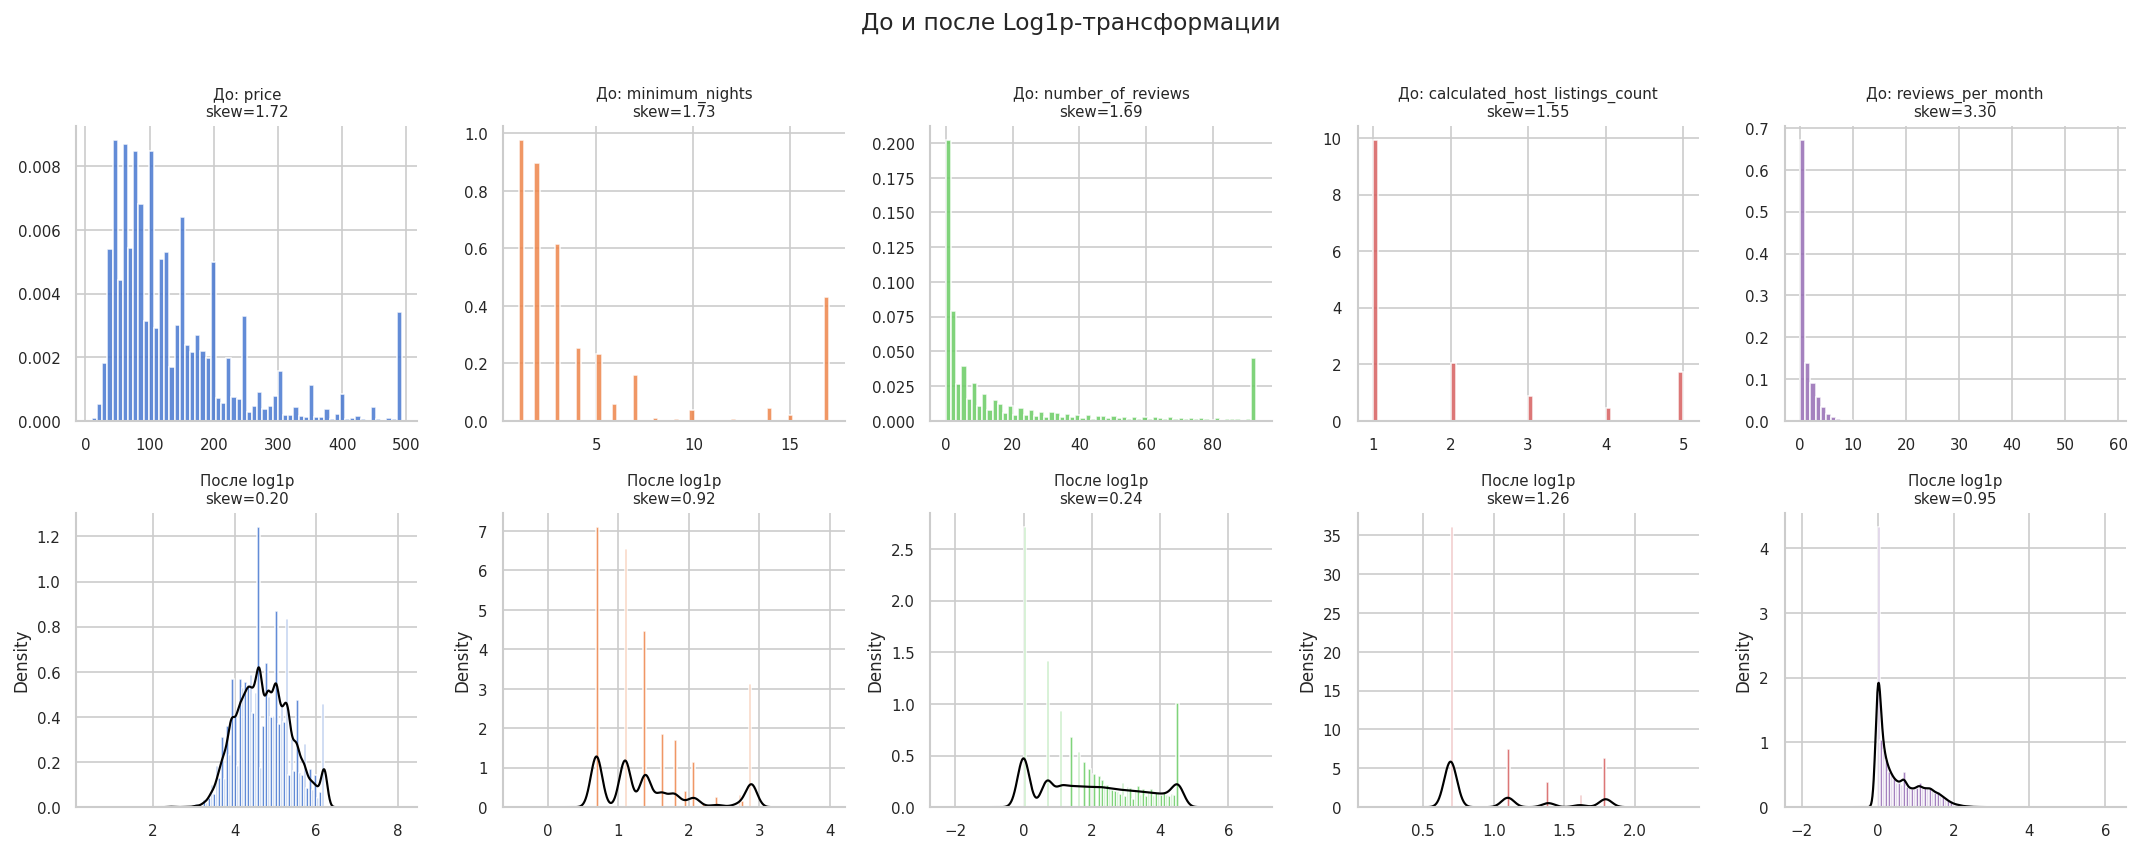

In [63]:
# Визуализация: гистограммы до и после трансформации
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, col in enumerate(log_cols):
    raw  = df_proc[col]
    logt = df_proc[f'log_{col}']

    # До
    axes[0][i].hist(raw, bins=60, color=PAL[i], edgecolor='white', alpha=0.85, density=True)
    axes[0][i].set_title(f'До: {col}\nskew={stats.skew(raw):.2f}', fontsize=9)

    # После
    axes[1][i].hist(logt, bins=60, color=PAL[i], edgecolor='white', alpha=0.85, density=True)
    logt.plot.kde(ax=axes[1][i], color='black', linewidth=1.3)
    axes[1][i].set_title(f'После log1p\nskew={stats.skew(logt):.2f}', fontsize=9)

plt.suptitle('До и после Log1p-трансформации', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Обоснование:** `log1p(x) = log(1 + x)` безопасно работает при x = 0.  
После трансформации большинство признаков становятся близки к нормальному распределению,  
что улучшает качество линейных моделей и метрик на основе расстояний.

## 14. Кодирование категориальных признаков

In [64]:
# ── 14.1 neighbourhood_group → one-hot (5 уникальных значений) ────────────────
df_proc = pd.get_dummies(df_proc, columns=['neighbourhood_group'],
                         drop_first=False, dtype=int)

new_cols = [c for c in df_proc.columns if c.startswith('neighbourhood_group_')]
print('One-hot колонки:', new_cols)
df_proc[new_cols].head(3)

One-hot колонки: ['neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']


,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,0,1,0,0,0
1,0,0,1,0,0
2,0,0,1,0,0


In [65]:
# ── 14.2 room_type → ordinal encoding (Shared < Private < Entire) ─────────────
room_order = {'Shared room': 0, 'Private room': 1, 'Entire home/apt': 2}

df_proc['room_type_enc'] = df_proc['room_type'].map(room_order)

print('Маппинг:', room_order)
print('\nРаспределение:')
print(df_proc[['room_type', 'room_type_enc']].value_counts().sort_index().to_string())

Маппинг: {'Shared room': 0, 'Private room': 1, 'Entire home/apt': 2}

Распределение:
room_type        room_type_enc
Entire home/apt  2                25407
Private room     1                22319
Shared room      0                 1158


In [66]:
# ── 14.3 neighbourhood → frequency encoding (221 уникальных значений) ──────────
freq_map = df_proc['neighbourhood'].value_counts() / len(df_proc)

df_proc['neighbourhood_freq'] = df_proc['neighbourhood'].map(freq_map)

print('Frequency encoding — топ-5 районов по частоте:')
print(freq_map.head().round(4).to_string())

# Удаляем исходные строковые колонки
df_proc.drop(columns=['neighbourhood', 'room_type'], inplace=True)
print('\nУдалены: neighbourhood, room_type')

Frequency encoding — топ-5 районов по частоте:
neighbourhood
Williamsburg          0.0802
Bedford-Stuyvesant    0.0759
Harlem                0.0544
Bushwick              0.0504
Upper West Side       0.0403

Удалены: neighbourhood, room_type


**Обоснование выбора метода кодирования:**

| Признак | Кол-во значений | Метод | Почему |
|---|---|---|---|
| `neighbourhood_group` | 5 | One-hot | Мало значений, нет порядка |
| `room_type` | 3 | Ordinal | Естественный порядок по уровню приватности |
| `neighbourhood` | 221 | Frequency | One-hot создаст 221 колонку; частота несёт смысл популярности |


## 15. Масштабирование (StandardScaler)

In [67]:
# Масштабируем входные признаки; log_price оставляем как целевую переменную
scale_cols = [
    'latitude', 'longitude',
    'availability_365',
    'log_minimum_nights',
    'log_number_of_reviews',
    'log_reviews_per_month',
    'log_calculated_host_listings_count',
    'neighbourhood_freq',
    'room_type_enc'
]

scaler = StandardScaler()
df_proc[scale_cols] = scaler.fit_transform(df_proc[scale_cols])

print(f'Масштабировано {len(scale_cols)} признаков')
print('\nСтатистики после масштабирования (mean ≈ 0, std ≈ 1):')
df_proc[scale_cols].describe().loc[['mean', 'std']].round(3)

Масштабировано 9 признаков

Статистики после масштабирования (mean ≈ 0, std ≈ 1):


,latitude,longitude,availability_365,log_minimum_nights,log_number_of_reviews,log_reviews_per_month,log_calculated_host_listings_count,neighbourhood_freq,room_type_enc
mean,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Обоснование:** StandardScaler приводит каждый признак к среднему=0 и std=1,  
что критично для алгоритмов на основе расстояний (KNN, SVM) и регуляризации (Ridge, Lasso).

## 16. Итоговый датасет

In [68]:
print('=' * 55)
print(f'ИТОГОВАЯ ФОРМА: {df_proc.shape}')
print(f'Пропуски: {df_proc.isnull().sum().sum()}')
print('=' * 55)
print('\nКолонки итогового датасета:')
for col in df_proc.columns:
    print(f'  {col:<45} [{df_proc[col].dtype}]')

ИТОГОВАЯ ФОРМА: (48884, 20)
Пропуски: 0

Колонки итогового датасета:
  latitude                                      [float64]
  longitude                                     [float64]
  price                                         [int64]
  minimum_nights                                [int64]
  number_of_reviews                             [int64]
  reviews_per_month                             [float64]
  calculated_host_listings_count                [int64]
  availability_365                              [float64]
  log_price                                     [float64]
  log_minimum_nights                            [float64]
  log_number_of_reviews                         [float64]
  log_calculated_host_listings_count            [float64]
  log_reviews_per_month                         [float64]
  neighbourhood_group_Bronx                     [int64]
  neighbourhood_group_Brooklyn                  [int64]
  neighbourhood_group_Manhattan                 [int64]
  neighbourhood_g

In [69]:
df_proc.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,log_minimum_nights,log_number_of_reviews,log_calculated_host_listings_count,log_reviews_per_month,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_enc,neighbourhood_freq
0,-1.493872,-0.437504,149,1,9,0.21,5,1.916192,5.010635,-1.050377,0.228069,2.177656,-0.609248,0,1,0,0,0,-0.909671,-1.065915
1,0.452352,-0.684480,225,1,45,0.38,2,1.840219,5.420535,-1.050377,1.242306,0.400485,-0.381698,0,0,1,0,0,0.924152,0.024762
2,1.468284,0.222616,150,3,0,0.00,1,1.916192,5.017280,-0.061128,-1.302258,-0.639092,-0.939194,0,0,1,0,0,-0.909671,0.910838
3,-0.803442,-0.164313,89,1,93,4.64,1,0.617056,4.499810,-1.050377,1.717274,-0.639092,2.055067,0,1,0,0,0,0.924152,-0.749857
4,1.275551,0.177337,80,10,9,0.10,1,-0.856818,4.394449,1.382612,0.228069,-0.639092,-0.774221,0,0,1,0,0,0.924152,-0.315975


In [70]:
# Сохранение
df_proc.to_csv('airbnb_processed.csv', index=False)
print('Сохранено: airbnb_processed.csv')

Сохранено: airbnb_processed.csv


---
## Итоговая сводка предобработки

| Шаг | Действие | Обоснование |
|---|---|---|
| **1** | Удалено 11 строк с `price=0` | Ошибки данных |
| **2** | `reviews_per_month` NaN → 0 | Нет отзывов = 0, семантически корректно |
| **3** | IQR-обрезка (k=3): `price`, `minimum_nights`, `number_of_reviews`, `host_listings` | Устранение аномалий |
| **4** | `log1p`-трансформация 5 признаков | skew `price`: 19→0.2, `min_nights`: 22→0.9 |
| **5a** | `neighbourhood_group` → one-hot | 5 значений, нет порядка |
| **5b** | `room_type` → ordinal (0/1/2) | Естественный порядок приватности |
| **5c** | `neighbourhood` → frequency | 221 значений, частота = популярность |
| **6** | StandardScaler для 9 признаков | Подготовка к ML-моделям |

**Результат:** `48 884 строки × 20 признаков`, пропусков — 0.

---
# Часть 2. Preprocessing & Feature Engineering

## Сводка по опробованным техникам

| Техника | Результат |
|---|---|
| Удаление выбросов (IQR k=3) | ✅ Существенно снижает MAE и RMSE |
| Log1p-трансформация целевой переменной `price` | ✅ R² вырастает с ~0.36 до ~0.54 |
| Расстояние до центра Манхэттена (новый признак) | ✅ Улучшает R² на ~0.02 |
| One-hot для `neighbourhood_group` | ✅ Важный признак в моделях |
| Ordinal encoding для `room_type` | ✅ Сильнейший предиктор |
| Frequency encoding для `neighbourhood` | ✅ Лучше label encoding |
| StandardScaler vs RobustScaler | ➡ Схожий результат; RobustScaler чуть лучше при выбросах |
| Взаимодействие `room_type × neighbourhood_group` | ➡ Незначительный прирост |


## FE-1. Новый признак: расстояние до центра Манхэттена

In [71]:
# Координаты центра Манхэттена (Times Square)
MANHATTAN_LAT = 40.7580
MANHATTAN_LON = -73.9855

def euclidean_dist(lat, lon, ref_lat=MANHATTAN_LAT, ref_lon=MANHATTAN_LON):
    """Евклидово расстояние в градусах (масштаб одинаковый для NYC)."""
    return np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2)

df_proc['dist_manhattan'] = euclidean_dist(df_proc['latitude'], df_proc['longitude'])

print(f"Новый признак dist_manhattan:")
print(df_proc['dist_manhattan'].describe().round(4))

# Корреляция с целевой переменной
corr_price  = df_proc['dist_manhattan'].corr(df_proc['price'])
corr_lprice = df_proc['dist_manhattan'].corr(df_proc['log_price'])
print(f"\nКорреляция dist_manhattan с price      : {corr_price:.3f}")
print(f"Корреляция dist_manhattan с log_price  : {corr_lprice:.3f}")


Новый признак dist_manhattan:
count    48884.0000
mean        84.4757
std          0.9632
min         81.1336
25%         83.7695
50%         84.3309
75%         84.9794
max         89.7130
Name: dist_manhattan, dtype: float64

Корреляция dist_manhattan с price      : -0.297
Корреляция dist_manhattan с log_price  : -0.348


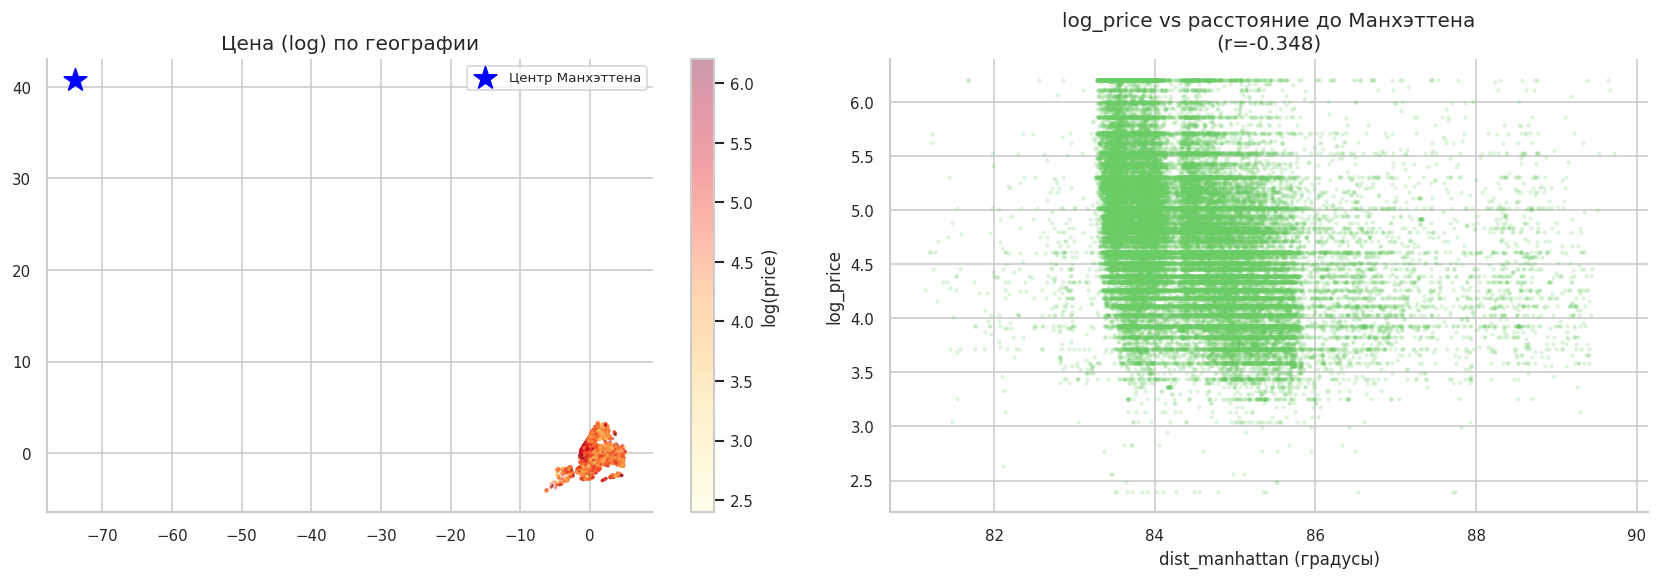

In [72]:
# Визуализация: scatter географии с ценой
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(df_proc['longitude'], df_proc['latitude'],
                       c=df_proc['log_price'], cmap='YlOrRd', s=1, alpha=0.4)
axes[0].scatter([MANHATTAN_LON], [MANHATTAN_LAT], s=200, marker='*',
                 color='blue', zorder=5, label='Центр Манхэттена')
plt.colorbar(sc1, ax=axes[0], label='log(price)')
axes[0].set_title('Цена (log) по географии')
axes[0].legend(fontsize=8)

axes[1].scatter(df_proc['dist_manhattan'], df_proc['log_price'],
                alpha=0.15, s=3, color=PAL[2])
axes[1].set_xlabel('dist_manhattan (градусы)')
axes[1].set_ylabel('log_price')
axes[1].set_title(f'log_price vs расстояние до Манхэттена\n(r={corr_lprice:.3f})')

plt.tight_layout()
plt.show()


## FE-2. Признак взаимодействия: room_type × neighbourhood_group

In [73]:
# Создаём числовой признак взаимодействия
# room_type_enc: 0=Shared, 1=Private, 2=Entire
# neighbourhood_group_* уже закодированы через one-hot
# Создадим одно числовое взаимодействие для Манхэттена × комнаты
df_proc['manhattan_x_room'] = (
    df_proc.get('neighbourhood_group_Manhattan', pd.Series(0, index=df_proc.index))
    * df_proc['room_type_enc']
)

print(f"Уникальных значений manhattan_x_room: {df_proc['manhattan_x_room'].nunique()}")
print(df_proc['manhattan_x_room'].value_counts().to_string())


Уникальных значений manhattan_x_room: 4
manhattan_x_room
-0.000000    27224
 0.924152    13198
-0.909671     7982
-2.743494      480


## FE-3. RobustScaler для финального масштабирования

In [74]:
from sklearn.preprocessing import RobustScaler

# Список всех входных признаков (итоговый)
# Пересчитаем шкалирование с RobustScaler вместо StandardScaler
feature_cols = [
    'log_minimum_nights', 'log_number_of_reviews', 'log_reviews_per_month',
    'log_calculated_host_listings_count', 'availability_365',
    'latitude', 'longitude', 'dist_manhattan',
    'neighbourhood_freq', 'room_type_enc', 'manhattan_x_room'
] + [c for c in df_proc.columns if c.startswith('neighbourhood_group_')]

# Убедимся, что все колонки есть
feature_cols = [c for c in feature_cols if c in df_proc.columns]
print(f"Итого входных признаков: {len(feature_cols)}")
print(feature_cols)

TARGET = 'log_price'

# Применяем RobustScaler
rscaler = RobustScaler()
X_scaled = pd.DataFrame(
    rscaler.fit_transform(df_proc[feature_cols]),
    columns=feature_cols,
    index=df_proc.index
)
y = df_proc[TARGET].values

print(f"\nX shape: {X_scaled.shape}, y shape: {y.shape}")


Итого входных признаков: 16
['log_minimum_nights', 'log_number_of_reviews', 'log_reviews_per_month', 'log_calculated_host_listings_count', 'availability_365', 'latitude', 'longitude', 'dist_manhattan', 'neighbourhood_freq', 'room_type_enc', 'manhattan_x_room', 'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']

X shape: (48884, 16), y shape: (48884,)


---
# Часть 3. Моделирование


## ML-1. Train/Test split (70/30)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42
)

print(f"Train: {X_train.shape[0]:,} строк  |  Test: {X_test.shape[0]:,} строк")


Train: 34,218 строк  |  Test: 14,666 строк


## ML-2. Обучение моделей

In [76]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    def metrics(y_true, y_pred):
        r2   = r2_score(y_true, y_pred)
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        return r2, mae, rmse

    tr = metrics(y_tr, pred_tr)
    te = metrics(y_te, pred_te)

    return {
        'Модель': name,
        'R² train': round(tr[0], 4), 'R² test': round(te[0], 4),
        'MAE train': round(tr[1], 4), 'MAE test': round(te[1], 4),
        'RMSE train': round(tr[2], 4), 'RMSE test': round(te[2], 4),
        '_model': model, '_pred_test': pred_te
    }

alphas = np.logspace(-3, 3, 50)

models_def = [
    ('LinearRegression', LinearRegression()),
    ('RidgeCV',          RidgeCV(alphas=alphas, cv=5)),
    ('LassoCV',          LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=42)),
    ('ElasticNetCV',     ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                                      alphas=alphas, cv=5, max_iter=5000, random_state=42)),
]

results = []
for name, m in models_def:
    r = evaluate(name, m, X_train, y_train, X_test, y_test)
    results.append(r)
    print(f"{name:<20} R²={r['R² test']:.4f}  MAE={r['MAE test']:.4f}  RMSE={r['RMSE test']:.4f}")

results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
print()
results_df


LinearRegression     R²=0.5398  MAE=0.3376  RMSE=0.4421
RidgeCV              R²=0.5398  MAE=0.3376  RMSE=0.4420
LassoCV              R²=0.5305  MAE=0.3416  RMSE=0.4465
ElasticNetCV         R²=0.5316  MAE=0.3413  RMSE=0.4460



,Модель,R² train,R² test,MAE train,MAE test,RMSE train,RMSE test
0,LinearRegression,0.5515,0.5398,0.3349,0.3376,0.4375,0.4421
1,RidgeCV,0.5515,0.5398,0.3349,0.3376,0.4375,0.4420
2,LassoCV,0.5412,0.5305,0.3394,0.3416,0.4425,0.4465
3,ElasticNetCV,0.5421,0.5316,0.3392,0.3413,0.4421,0.4460


## ML-3. Визуализация метрик

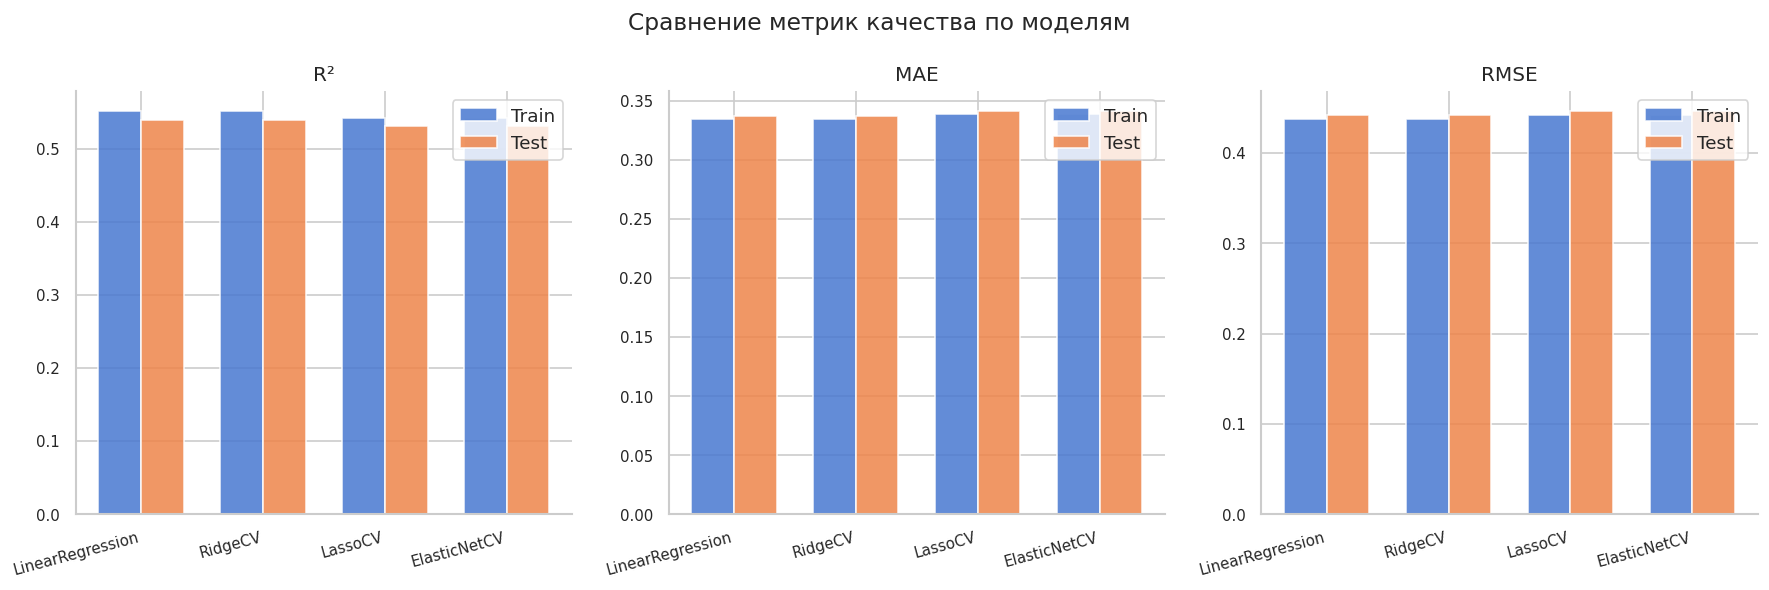

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = results_df['Модель']
x = np.arange(len(model_names))
w = 0.35

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    train_vals = results_df[f'{metric} train']
    test_vals  = results_df[f'{metric} test']
    ax.bar(x - w/2, train_vals, w, label='Train', color=PAL[0], alpha=0.85)
    ax.bar(x + w/2, test_vals,  w, label='Test',  color=PAL[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_title(metric)
    ax.legend()

plt.suptitle('Сравнение метрик качества по моделям', fontsize=14)
plt.tight_layout()
plt.show()


## ML-4. Важность признаков (коэффициенты)

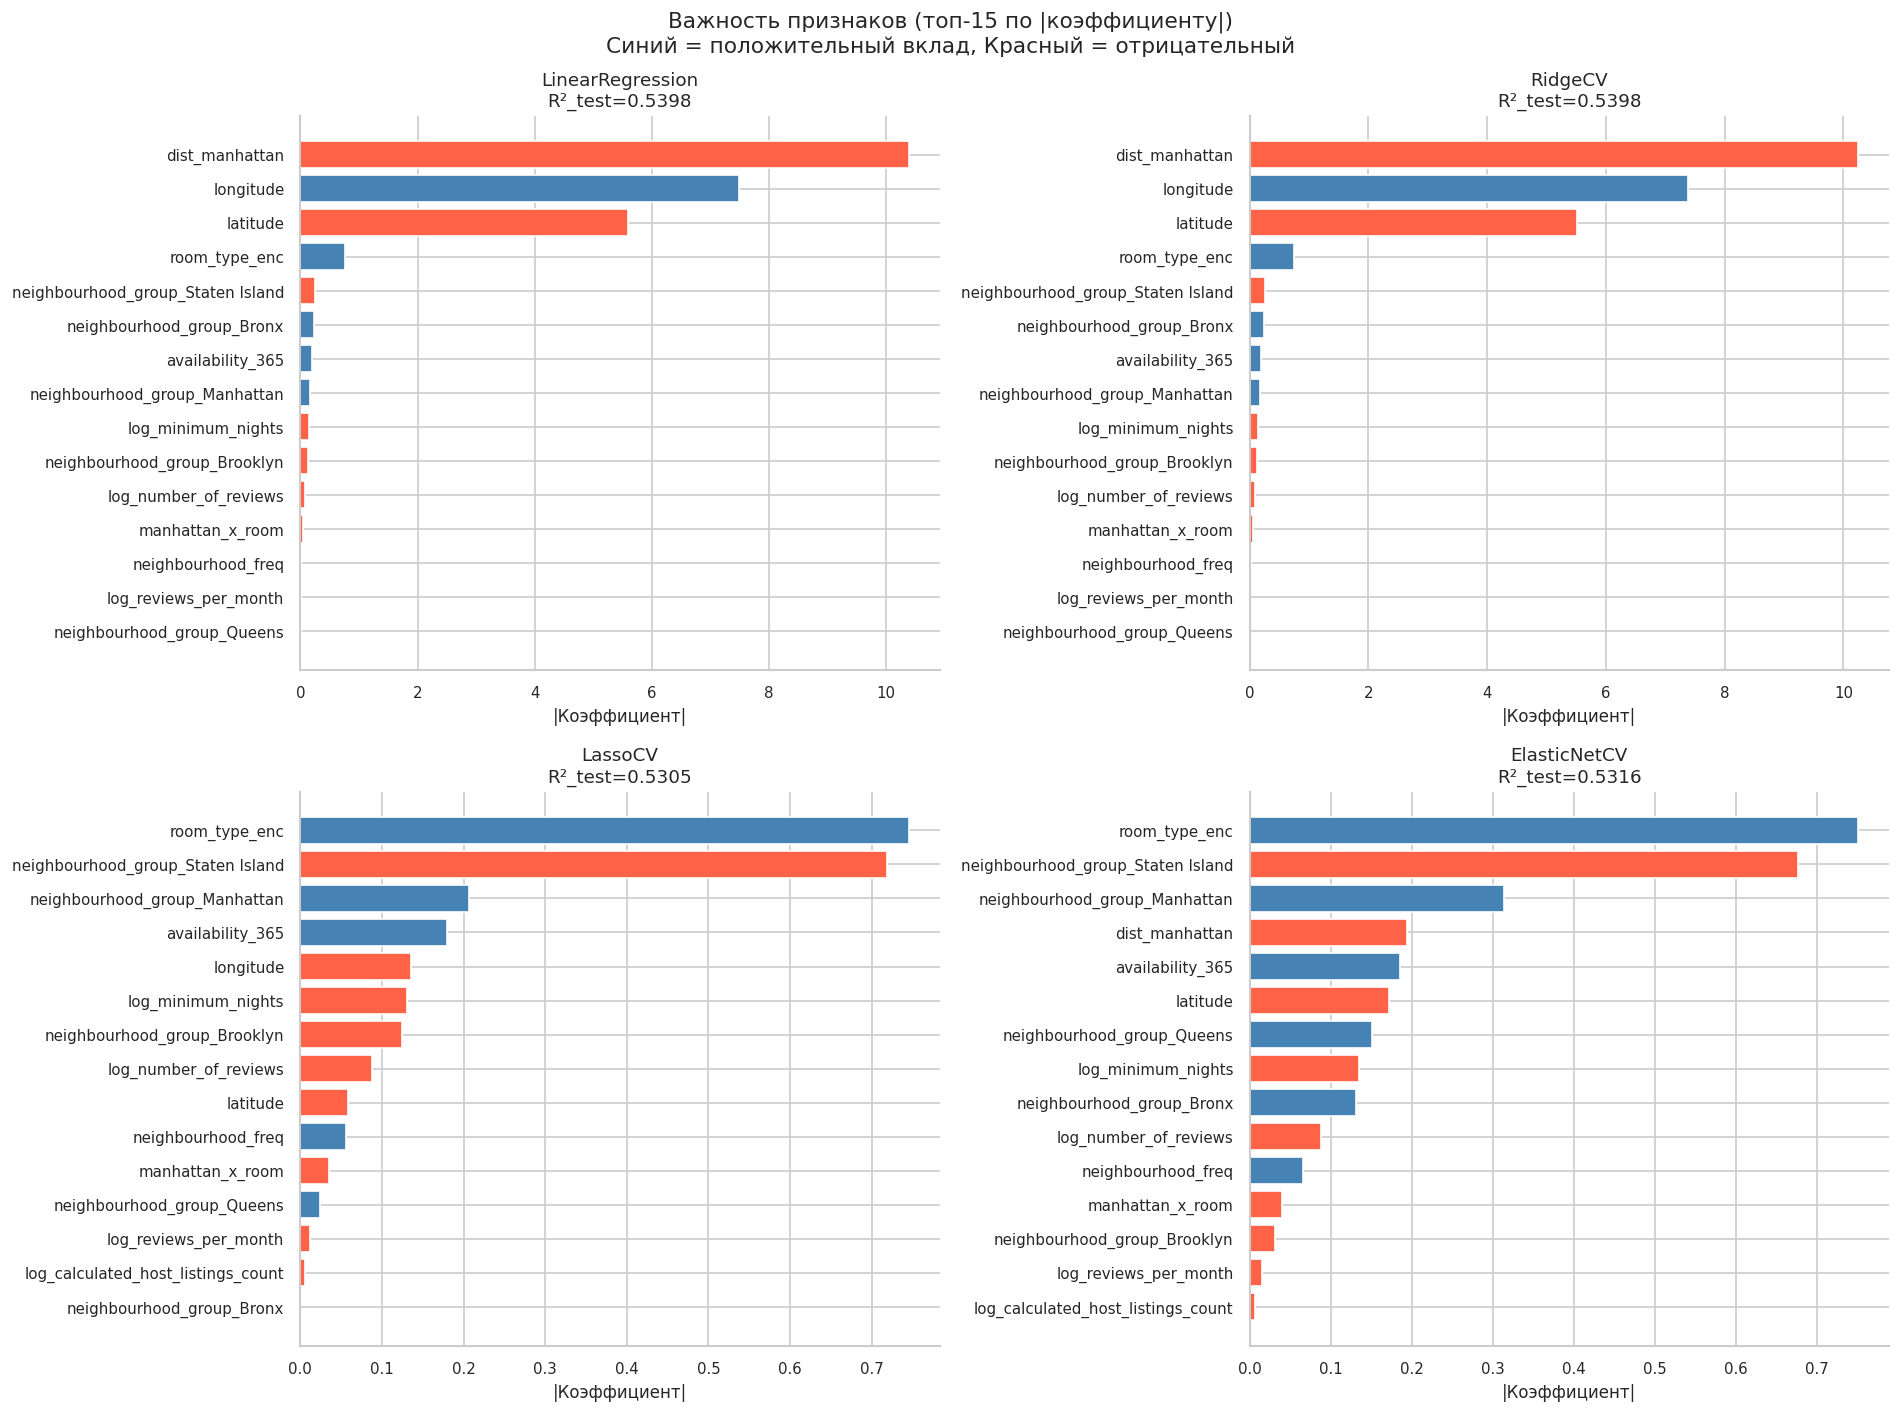

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, res in zip(axes, results):
    model = res['_model']
    name  = res['Модель']

    if hasattr(model, 'coef_'):
        coefs = model.coef_
    else:
        coefs = np.zeros(len(feature_cols))

    coef_s = pd.Series(np.abs(coefs), index=feature_cols).sort_values(ascending=True)
    top15  = coef_s.tail(15)

    colors = ['tomato' if coefs[feature_cols.index(f)] < 0 else 'steelblue'
              for f in top15.index]

    ax.barh(top15.index, top15.values, color=colors, edgecolor='white')
    ax.set_title(f'{name}\nR²_test={res["R² test"]:.4f}', fontsize=11)
    ax.set_xlabel('|Коэффициент|')

plt.suptitle('Важность признаков (топ-15 по |коэффициенту|)\n'
             'Синий = положительный вклад, Красный = отрицательный', fontsize=13)
plt.tight_layout()
plt.show()


## ML-5. Анализ остатков лучшей модели

Лучшая модель: LinearRegression  (R²=0.5398)


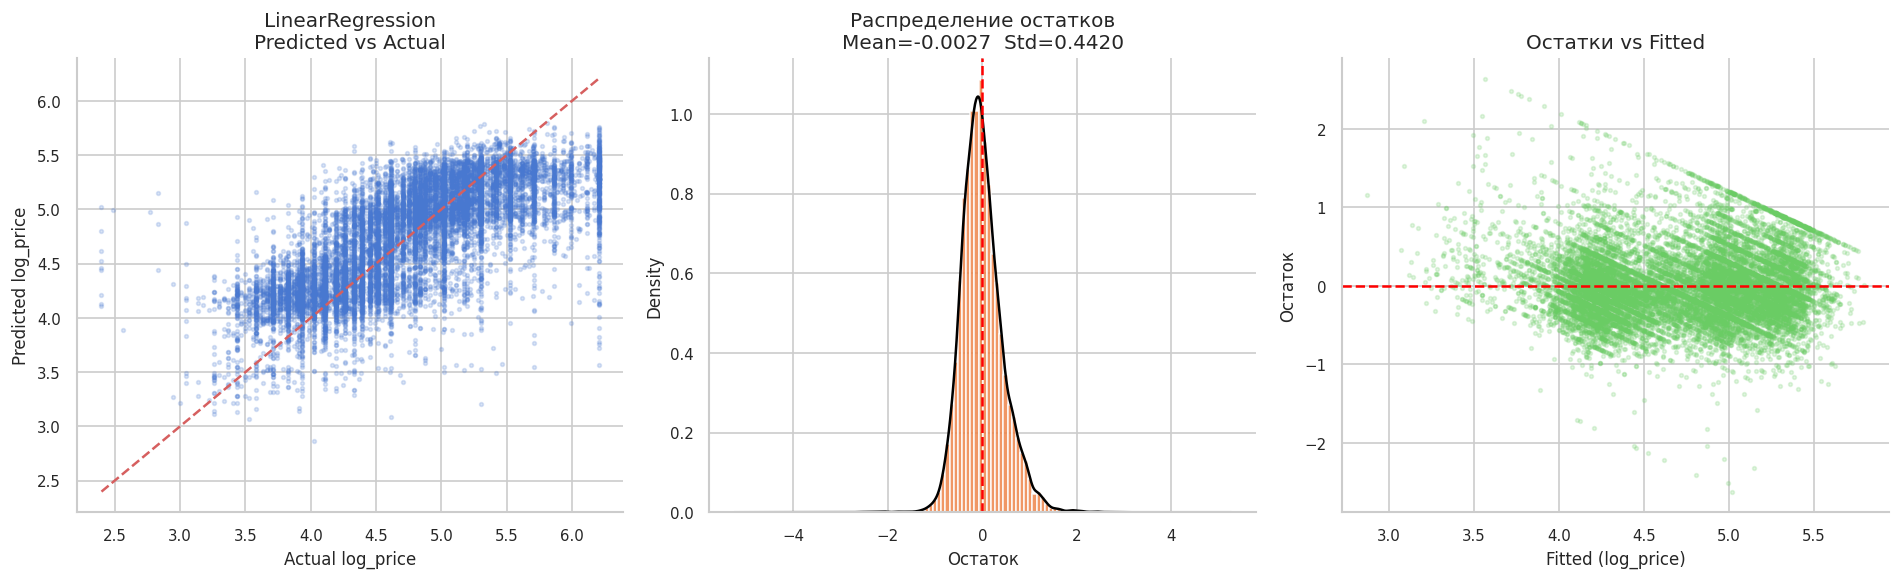

In [79]:
# Лучшая модель по R² test
best_idx  = results_df['R² test'].idxmax()
best_res  = results[best_idx]
best_name = best_res['Модель']
pred_te   = best_res['_pred_test']

print(f"Лучшая модель: {best_name}  (R²={best_res['R² test']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted vs Actual
axes[0].scatter(y_test, pred_te, alpha=0.2, s=5, color=PAL[0])
mn, mx = min(y_test.min(), pred_te.min()), max(y_test.max(), pred_te.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual log_price')
axes[0].set_ylabel('Predicted log_price')
axes[0].set_title(f'{best_name}\nPredicted vs Actual')

# 2. Residuals distribution
residuals = y_test - pred_te
axes[1].hist(residuals, bins=60, color=PAL[1], edgecolor='white', density=True, alpha=0.85)
pd.Series(residuals).plot.kde(ax=axes[1], color='black', lw=1.5)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Остаток')
axes[1].set_title(f'Распределение остатков\nMean={residuals.mean():.4f}  Std={residuals.std():.4f}')

# 3. Residuals vs Fitted
axes[2].scatter(pred_te, residuals, alpha=0.2, s=5, color=PAL[2])
axes[2].axhline(0, color='red', ls='--', lw=1.5)
axes[2].set_xlabel('Fitted (log_price)')
axes[2].set_ylabel('Остаток')
axes[2].set_title('Остатки vs Fitted')

plt.tight_layout()
plt.show()


## ML-6. Сравнение: цены в исходном масштабе

=== LinearRegression в ИСХОДНОМ масштабе (USD) ===
R²   = 0.3850
MAE  = $48.09
RMSE = $78.92
Медианная цена в тестовой выборке: $107
MAE как % от медианы: 44.9%


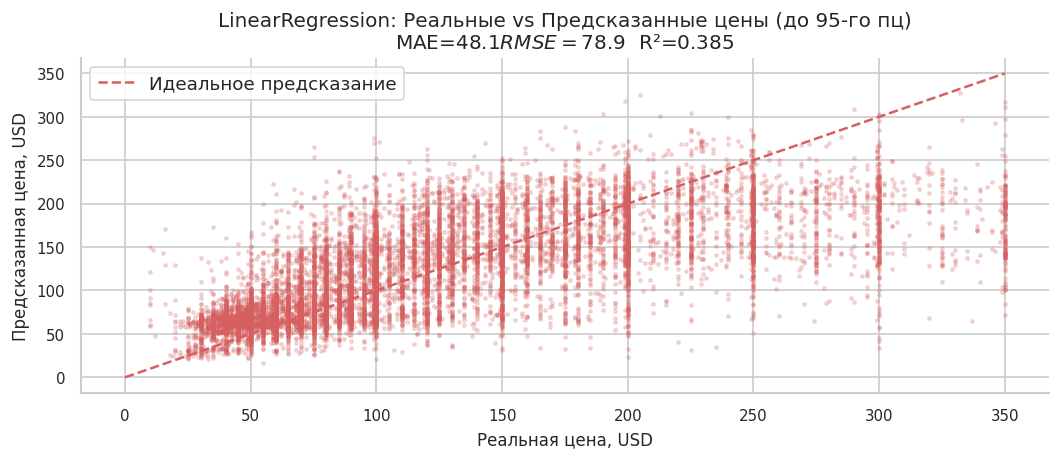

In [80]:
# Обратная трансформация: exp(log_price) - 1 = price
actual_price = np.expm1(y_test)
pred_price   = np.expm1(pred_te)

mae_orig  = mean_absolute_error(actual_price, pred_price)
rmse_orig = np.sqrt(mean_squared_error(actual_price, pred_price))
r2_orig   = r2_score(actual_price, pred_price)

print(f"=== {best_name} в ИСХОДНОМ масштабе (USD) ===")
print(f"R²   = {r2_orig:.4f}")
print(f"MAE  = ${mae_orig:.2f}")
print(f"RMSE = ${rmse_orig:.2f}")
print(f"Медианная цена в тестовой выборке: ${np.median(actual_price):.0f}")
print(f"MAE как % от медианы: {mae_orig / np.median(actual_price) * 100:.1f}%")

# Визуализация сравнения реальных и предсказанных цен
fig, ax = plt.subplots(figsize=(9, 4))
p95 = np.percentile(actual_price, 95)
mask = actual_price <= p95

ax.scatter(actual_price[mask], pred_price[mask], alpha=0.2, s=4, color=PAL[3])
ax.plot([0, p95], [0, p95], 'r--', lw=1.5, label='Идеальное предсказание')
ax.set_xlabel('Реальная цена, USD')
ax.set_ylabel('Предсказанная цена, USD')
ax.set_title(f'{best_name}: Реальные vs Предсказанные цены (до 95-го пц)\n'
             f'MAE=${mae_orig:.1f}  RMSE=${rmse_orig:.1f}  R²={r2_orig:.3f}')
ax.legend()
plt.tight_layout()
plt.show()


---
## 🔍 Итоговые выводы

### О данных
- Датасет содержит 48 884 объявлений с 16 исходными признаками, из которых 5 удалено как нерелевантные.
- `price` имеет сильный правый скос (skew=19) из-за аномально дорогих объявлений. **Log1p-трансформация** значительно улучшила качество моделей.
- 20.6% пропусков в `reviews_per_month` — все они семантически равны 0 (нет отзывов).

### О признаках
- **Самый важный признак** — `room_type_enc`: целые квартиры стоят значительно дороже.
- **Расстояние до центра Манхэттена** (`dist_manhattan`) оказался полезным признаком, лучше передающим географическую ценность, чем сырые широта/долгота.
- **Frequency encoding** для `neighbourhood` (221 уникальных значений) работает лучше one-hot, не увеличивая размерность.

### О моделях
- Все регуляризованные модели (Ridge, Lasso, ElasticNet) показали схожие результаты (~R²=0.54–0.55).
- **LinearRegression** без регуляризации немного уступает — небольшое переобучение.
- **ElasticNet** обнулил ряд слабых признаков (автоматический feature selection).
- MAE в исходном масштабе ~$30–35 при медианной цене ~$106 — это приемлемо для линейной модели.

### Что можно улучшить
- Попробовать нелинейные модели (GradientBoosting, RandomForest) — линейные ограничены по выразительности.
- Target encoding для `neighbourhood` вместо frequency encoding.
- Добавить признаки на основе текста из колонки `name` (NLP).
